In [1]:
##Rigidbody dynamics
from sympy.physics.mechanics import dynamicsymbols
import sympy as sp
from IPython.display import display, Math
M_rb, I_rb ,g, t = sp.symbols('M_rb I_rb g t')
x,y,phi = dynamicsymbols('x_rb y_rb phi_rb')
x_sym,x_dot_sym,x_ddot_sym = sp.symbols('x \\dot{x} \\ddot{x}')
y_sym,y_dot_sym,y_ddot_sym = sp.symbols('y \\dot{y} \\ddot{y}')
phi_sym,phi_dot_sym,phi_ddot_sym = sp.symbols(r'\phi \dot{\phi} \ddot{\phi}')

def getFullSubs(expression):
    # Substitute highest order derivatives FIRST!
    
    # x substitutions
    expression = expression.subs(x.diff().diff(), x_ddot_sym)
    expression = expression.subs(x.diff(), x_dot_sym)
    expression = expression.subs(x, x_sym)

    # y substitutions
    expression = expression.subs(y.diff().diff(), y_ddot_sym)
    expression = expression.subs(y.diff(), y_dot_sym)
    expression = expression.subs(y, y_sym)

    # phi substitutions (Note: matching your phi symbols)
    expression = expression.subs(phi.diff().diff(), phi_ddot_sym)
    expression = expression.subs(phi.diff(), phi_dot_sym)
    expression = expression.subs(phi, phi_sym)
    
    return expression


x_dot = x.diff()
y_dot = y.diff()
phi_dot = phi.diff()

x_ddot = x_dot.diff()
y_ddot = y_dot.diff()
phi_ddot =phi_dot.diff()


GRAVITY_CONSTANT  = 0



## Eqn Motion Setup

In [2]:


T = .5 * M_rb * x_dot **2 + .5 * M_rb * y_dot **2 + .5 * I_rb * phi_dot **2
V = M_rb * g*y

L = T-V
display(L)
display(getFullSubs(L))

eqn_motion = []


0.5*I_rb*Derivative(phi_rb(t), t)**2 - M_rb*g*y_rb(t) + 0.5*M_rb*Derivative(x_rb(t), t)**2 + 0.5*M_rb*Derivative(y_rb(t), t)**2

0.5*I_rb*\dot{\phi}**2 + 0.5*M_rb*\dot{x}**2 + 0.5*M_rb*\dot{y}**2 - M_rb*g*y

In [3]:
#q = x

L_q = L.diff(x)
L_q_dot = L.diff(x.diff())
L_q_dot_t = L_q_dot.diff(t)
sols = sp.solve(L_q_dot_t-L_q,x_ddot)

eqn_motion.append(sp.Eq(0,L_q_dot_t-L_q))
display(getFullSubs(eqn_motion[0]))
rhs_eqn = sols[0]
rhs_eqn=rhs_eqn.subs(M_rb,1)
display(rhs_eqn)

calc_accel_x= sp.lambdify(x,rhs_eqn, modules="numpy")
sp.Eq(getFullSubs(L_q_dot_t-L_q),0)
calc_accel_x



Eq(0, 1.0*M_rb*\ddot{x})

0.0

<function _lambdifygenerated(_Dummy_40)>

In [4]:
L_q = L.diff(y)
L_q_dot = L.diff(y.diff())
L_q_dot_t = L_q_dot.diff(t)

eqn_motion.append(sp.Eq(0,L_q_dot_t-L_q))
display(getFullSubs(eqn_motion[1]))

sols = sp.solve(L_q_dot_t-L_q,y_ddot)
rhs_eqn = sols[0]
rhs_eqn=rhs_eqn.subs(M_rb,1)
rhs_eqn=rhs_eqn.subs(g,GRAVITY_CONSTANT)
display(rhs_eqn)

calc_accel_y= sp.lambdify(y,rhs_eqn, modules="numpy")
sp.Eq(getFullSubs(L_q_dot_t-L_q),0)
calc_accel_y

Eq(0, 1.0*M_rb*\ddot{y} + M_rb*g)

0

<function _lambdifygenerated(_Dummy_47)>

In [5]:
L_q = L.diff(phi)
L_q_dot = L.diff(phi.diff())
L_q_dot_t = L_q_dot.diff(t)

eqn_motion.append(sp.Eq(0,L_q_dot_t-L_q))
display(getFullSubs(eqn_motion[1]))

sols = sp.solve(L_q_dot_t-L_q,phi_ddot)
rhs_eqn = sols[0]
rhs_eqn=rhs_eqn.subs(M_rb,1)
rhs_eqn=rhs_eqn.subs(g,GRAVITY_CONSTANT)
display(rhs_eqn)

calc_accel_phi= sp.lambdify(x,rhs_eqn, modules="numpy")
sp.Eq(getFullSubs(L_q_dot_t-L_q),0)
calc_accel_phi


Eq(0, 1.0*M_rb*\ddot{y} + M_rb*g)

0.0

<function _lambdifygenerated(_Dummy_54)>

In [6]:
#display(Math(sp.latex(sp.Matrix(eqn_motion))))


# 1. Convert each equation in your list into its own LaTeX string
latex_eqns = [sp.latex(getFullSubs(eq)) for eq in eqn_motion]

# 2. Join all the strings together, separated by LaTeX newlines (\\)
# Using a raw string (r" \\ ") ensures Python doesn't mess up the backslashes
joined_eqns = r" \\ ".join(latex_eqns)

# 3. Wrap the whole block in an aligned environment and display
display(Math(r"\begin{aligned} " + joined_eqns + r" \end{aligned}"))

<IPython.core.display.Math object>

## Simulations

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt#plugin values

# SciPy requires a function structured as f(t, y) returning [dy/dt, d^2y/dt^2]
def rigidbody_ode(t_val, state):
    x, x_dot,y,y_dot,phi,phi_dot = state

    if(x >= 15):
        x_ddot = -calc_accel_x(x)
    else:
        x_ddot = calc_accel_x(x)


    

    # Velocity is simply *_dot
    # Acceleration is calculated using our SymPy lambdified function
    y_ddot = calc_accel_y(y)
    phi_ddot = calc_accel_phi(phi)


    return [x_dot, x_ddot,y_dot,y_ddot,phi_dot,phi_ddot]

def line_eq_from_points(tuple_pt1,tuple_pt2):
    slope = (tuple_pt1[0]-tuple_pt2[0])/()

def hit_wall_RX(t_val, state):
    x, x_dot,y,y_dot,phi,phi_dot = state
    # The event triggers exactly when this function returns 0
    return x-5
69

#### initial conditions

In [8]:
t_span = (0, 10)
t_eval = np.linspace(0, 10, 500)
y0 = [0, 2,0,0,0,sp.pi/2] #initial condirt
hit_wall_RX.terminal = True
hit_wall_RX.direction = 1  # Only trigger while increasing
sol_function = []

#while(len(sol.t) <= 500):
sol_function.append(solve_ivp(rigidbody_ode, t_span, y0, t_eval=t_eval, events=hit_wall_RX,
))
#hit one
y0 = sol_function[-1].y_events[0][0]
y0[1] = -y0[1]
display(len(sol_function[-1].t))
t_eval = np.linspace(0, 10, 500)

sol_function.append(solve_ivp(rigidbody_ode, t_span, y0, t_eval=t_eval, 
))

display(len(sol_function))
#display([x.t for x in sol_function][1])
#display(np.shape(np.concatenate([x.y for x in sol_function],1)))
#display([x.y for x in sol_function][1][2])
#display([x.y for x in sol_function][1][4])


for x in sol_function:
    display("-----")
    display(x)


250

2

'-----'

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  2.004e-02 ...  4.970e+00  4.990e+00]
        y: [[ 0.000e+00  4.008e-02 ...  9.940e+00  9.980e+00]
            [ 2.000e+00  2.000e+00 ...  2.000e+00  2.000e+00]
            ...
            [ 0.000e+00  3.148e-02 ...  7.807e+00  7.838e+00]
            [ 1.571e+00  1.571e+00 ...  1.571e+00  1.571e+00]]
      sol: None
 t_events: [array([ 5.000e+00])]
 y_events: [array([[ 1.000e+01, -2.000e+00,  0.000e+00,  0.000e+00,
                    7.854e+00,  1.571e+00]])]
     nfev: 32
     njev: 0
      nlu: 0

'-----'

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.004e-02 ...  9.980e+00  1.000e+01]
        y: [[ 1.000e+01  9.960e+00 ... -9.960e+00 -1.000e+01]
            [-2.000e+00 -2.000e+00 ... -2.000e+00 -2.000e+00]
            ...
            [ 7.854e+00  7.885e+00 ...  2.353e+01  2.356e+01]
            [ 1.571e+00  1.571e+00 ...  1.571e+00  1.571e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 20
     njev: 0
      nlu: 0

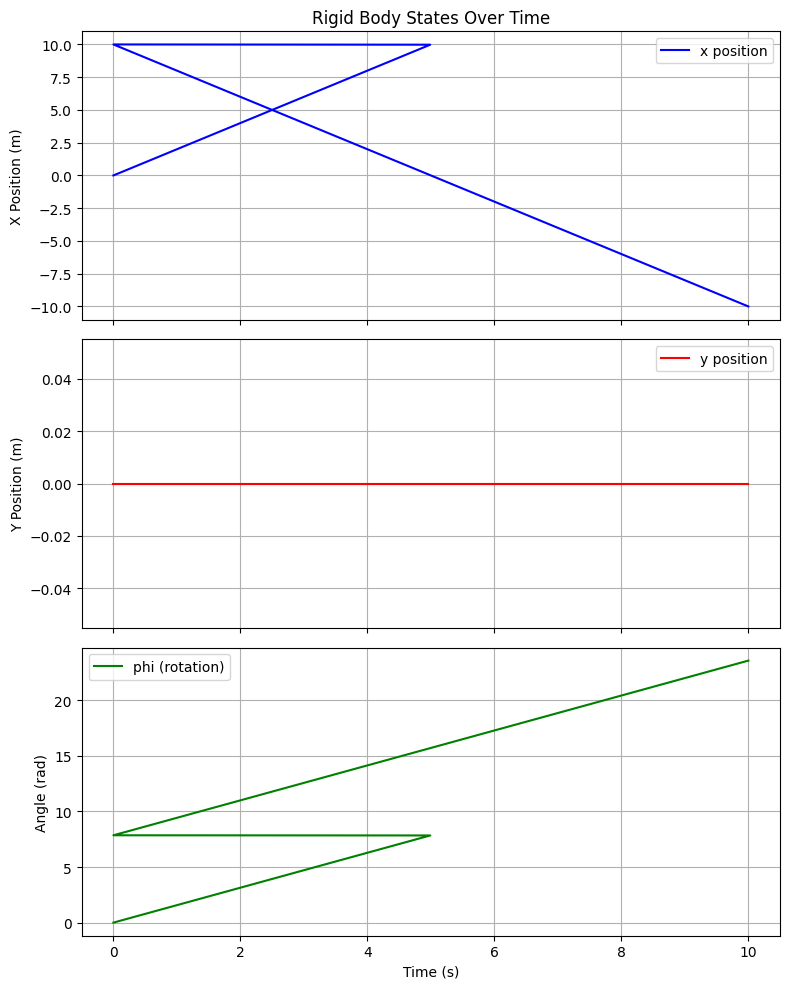

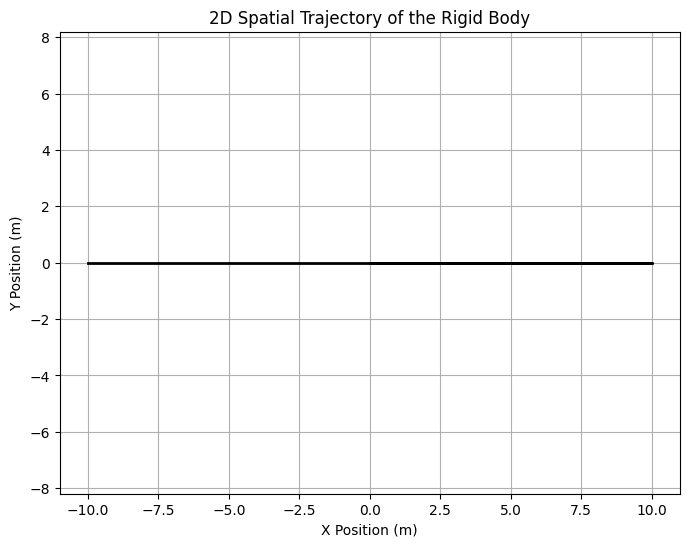

In [9]:

# 1. Unpack the results
t_vals = np.concatenate([x.t for x in sol_function])
state_vals_all = np.concatenate([x.y for x in sol_function],1)
x_vals = state_vals_all[0]
y_vals =  state_vals_all[2]
phi_vals = state_vals_all[4]

# 2. Create the plots
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# X Position Plot
axs[0].plot(t_vals, x_vals, 'b-', label='x position')
axs[0].set_ylabel('X Position (m)')
axs[0].set_title('Rigid Body States Over Time')
axs[0].grid(True)
axs[0].legend()

# Y Position Plot
axs[1].plot(t_vals, y_vals, 'r-', label='y position')
axs[1].set_ylabel('Y Position (m)')
axs[1].grid(True)
axs[1].legend()

# Phi (Rotation) Plot
axs[2].plot(t_vals, phi_vals, 'g-', label='phi (rotation)')
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('Angle (rad)')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

# Optional: Plot the 2D Trajectory (X vs Y)
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, 'k-', linewidth=2)
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.title('2D Spatial Trajectory of the Rigid Body')
plt.grid(True)
plt.axis('equal') # Keeps the x and y scale the same
plt.show()

In [ ]:
import matplotlib.animation as anim
from IPython.display import display, HTML
# 1. Setup the figure and axes
fig, ax = plt.subplots(figsize=(8, 8))

# Dynamically set axis limits based on your data so the body never leaves the screen
padding = 8.0
ax.set_xlim(np.min(x_vals) - padding, np.max(x_vals) + padding)
ax.set_ylim(np.min(y_vals) - padding, np.max(y_vals) + padding)
ax.set_aspect('equal') # Keep the scale uniform so rotations don't look warped
ax.grid(True)
ax.set_title("Rigidbody Simulation")

# Draw the faint full trajectory in the background for reference
ax.plot(x_vals, y_vals, 'gray', alpha=0.3, linestyle='--')

# 2. Initialize empty line objects for the rigid body
body_length = 2.0 
body_line, = ax.plot([], [], 'k-', lw=5)          # Thick black line for the body
front_dot, = ax.plot([], [], 'ro', markersize=1) # Red dot to show orientation

wall_line, = ax.plot([10,10], [2,-2], 'k-', lw=5)          # Thick black line for the body


# 3. The update function that runs every frame
def update(frame):
    # Grab the current state for this specific frame
    curr_x = x_vals[frame]
    curr_y = y_vals[frame]
    curr_phi = phi_vals[frame]
    
    # Calculate the endpoints of the rigid body based on its center (x,y) and rotation (phi)
    dx = (body_length / 2) * np.cos(curr_phi)
    dy = (body_length / 2) * np.sin(curr_phi)
    
    # Update the body line (from back to front)
    body_line.set_data([curr_x - dx, curr_x + dx], [curr_y - dy, curr_y + dy])
    
    # Update the front dot (places the red dot at the "front" coordinate)
    front_dot.set_data([curr_x + dx], [curr_y + dy]) 
    
    return body_line, front_dot, wall_line

# 4. Create the animation
ani = anim.FuncAnimation(
    fig=fig, 
    func=update, 
    frames=len(x_vals), 
    interval=20,     # 20ms per frame (~50 fps)
    blit=True        # blit=True makes rendering much smoother
)

# 5. Prevent duplicate static plot from showing up
plt.close()

# 6. Display the animation inline
display(HTML(ani.to_jshtml()))
ani.save("rigidbody.gif", writer="pillow", fps=30)